## 5ª Tarefa de Oficina de Modelagem e Simulação

**Autor:** Arthur Vinícius de Oliveira Carvalho  
**Instituição:** UFMG  
**Data:** 11 de abril de 2026  

---

### Descrição
Exercícios computacionais

---

**1.** *O sistema da Figura 7 á submetido a uma forçaa impulsiva $f(t) = f0δ(t)$, com $f0$ a amplitude do impulso. Determine a função de transferência do sistema e, usando o Matlab (usaremos python), apresente o deslocamento da massa $m$ em função do tempo. Dados $m = 1 kg$, $c = 10 Ns/m$, $f0 = 100 N$.*

**Resposta:**  

Modelagem - pela segunda lei de Newton, $m\ddot{x}(t)+c\dot{x}(t)=f(t)$, substituindo os valores $m = 1kg, c = 10N, f_0 = 100N$ e $f(t) = f_0\delta(t)$, temos: $\ddot{x}(t)+10\dot{x}(t) = 100\delta(t)$  

Aplicando a trasnformada de Laplace, $X(s)(ms2+cs)=F(s)$, $G(s) = \frac{1}{s^2+10s}$.


Função de Transferência:
         1
-------------------
1s² + 10s



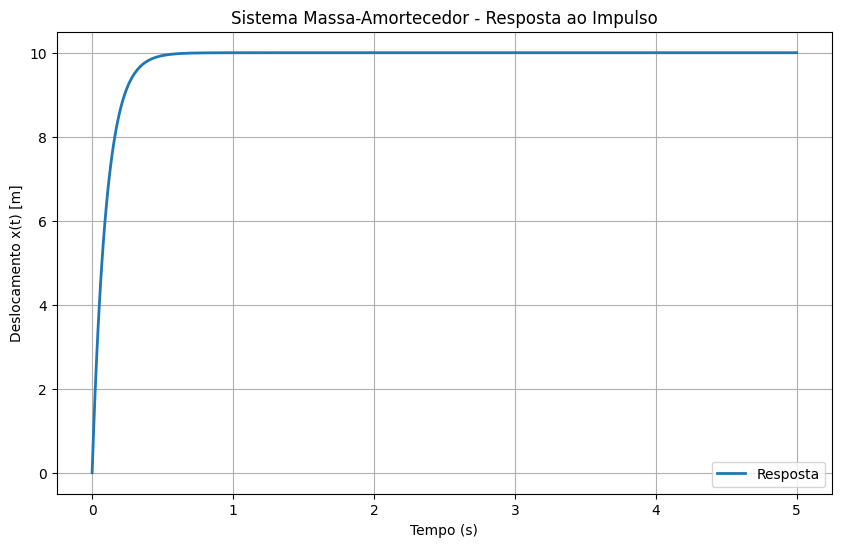

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parameters
m = 1       # massa (kg)
c = 10      # amortecimento (N.s/m)
f0 = 100    # Amplitude (N)

# Função de Transferência
num = [1]
dem = [m, c, 0]

system = signal.TransferFunction(num, dem)

print("Função de Transferência:")
print("         1")
print("-------------------")
print(f"{m}s² + {c}s")
print()

# Vetor de tempo
t = np.linspace(0, 5, 500)

# Resposta ao impulso
t, xt = signal.impulse(system, T=t)
xt = f0*xt

# Plot 
plt.figure(figsize=(10,6))
plt.plot(t, xt, label='Resposta', linewidth=2)
plt.title('Sistema Massa-Amortecedor - Resposta ao Impulso')
plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento x(t) [m]')
plt.grid(True)
plt.legend()
plt.show()



---

**2.** *Idem exercício 1, porém agora a excitação é uma forçaa constante $f(t) = f0u(t)$. Compare a forma do gráfico com o da Figura 4.*

Função de Transferência:
         1
-------------------
1s² + 10s



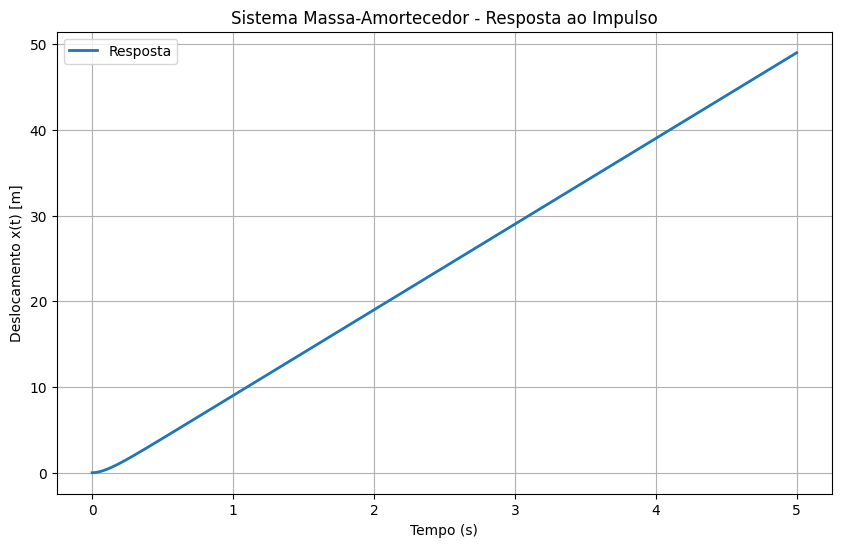

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parameters
m = 1       # massa (kg)
c = 10      # amortecimento (N.s/m)
f0 = 100    # Amplitude (N)

# Função de Transferência
num = [1]
dem = [m, c, 0]

system = signal.TransferFunction(num, dem)

print("Função de Transferência:")
print("         1")
print("-------------------")
print(f"{m}s² + {c}s")
print()

# Vetor de tempo
t = np.linspace(0, 5, 500)

# Resposta ao impulso
t, xt = signal.step(system, T=t)
xt = f0*xt

# Plot 
plt.figure(figsize=(10,6))
plt.plot(t, xt, label='Resposta', linewidth=2)
plt.title('Sistema Massa-Amortecedor - Resposta ao Degrau')
plt.xlabel('Tempo (s)')
plt.ylabel('Deslocamento x(t) [m]')
plt.grid(True)
plt.legend()
plt.show()

"""
    Por ser de segunda ordem, a figura 4 apresenta oscilações, já este sismeta, não apresenda oscilações
"""

---

**3.** *Um sistema mecâico sem amortecimento, com $m = 1kg$ e $k = 100N/m$, inicialmente em repouso, é submetido a uma força constante com módulo $f0 = 10N$. Apresente, graficamente, a resposta do sistema.*

**Resposta:**  

Vamos supor que se trata de um sistema massa-mola. então a EDO seria $m\ddot{x}+k\dot{x}=f(t)$. Que nos dá a TF: $G(s) = \frac{1}{s^2+100}$

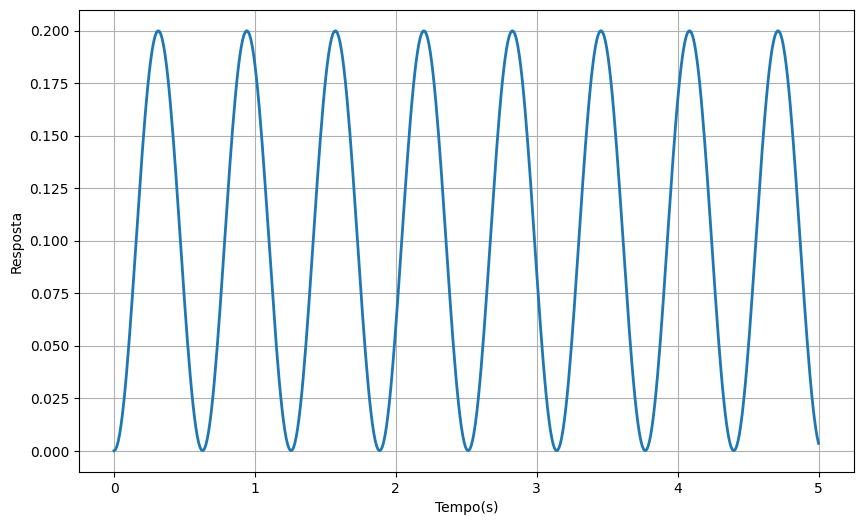

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Paramaetros
m = 1       # massa (kg)
k = 100     # rigidez (N/m)
f0 = 10    # Amplitude (N)

# Função de Transferência
num = [1]
dem = [m, 0, k]
system = signal.TransferFunction(num, dem)

# Vetor de tempo
t = np.linspace(0, 5, 500)

# Resposta
t, x = signal.step(system, T=t)
x = f0 * x

# Plot
plt.figure(figsize=(10,6))
plt.plot(t, x, label='Resposta', linewidth=2)
plt.xlabel('Tempo(s)')
plt.ylabel('Resposta')
plt.grid()
plt.show()

---

**4.** *A partir da equação (6), deduzir uma expressão para a resposta do sistema do exercício anterior e graficá-la usando MatLab (python), comparando-a com o gráfico obtido anteriormente.*

**Resposta:**  

Como o sistem não possui amortecimento $\zeta = 0$, $\omega_n = \omega_D = \sqrt{\frac{k}{m}} = 10$ e $a = \frac{k}{f0} = 10$. Substituindo, a equação 6 se torna: $$x_u(t) = 0.1(1 - cos(10*t))$$

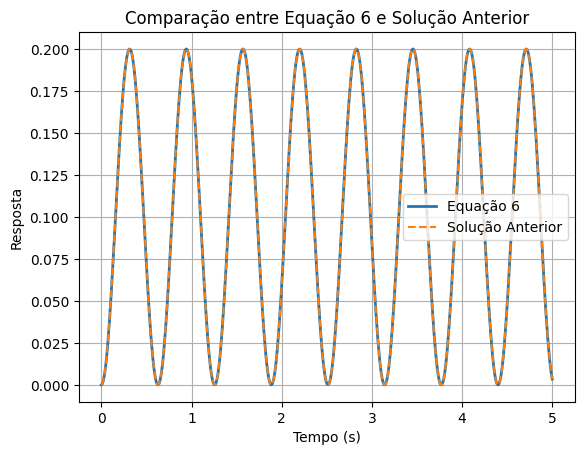

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Paramaetros
m = 1    
k = 100     
f0 = 10   

wn = np.sqrt(k/m)
zeta = 0
wd = wn
a = k/f0

# Vetor de tempo
t = np.linspace(0, 5, 500)

# Esquação 6
x_eq6 = (1/a) * (
    1 - np.exp(-zeta * wn * t) *
    (
        np.cos(wd * t)
        + ((zeta * wn) / wd) * np.sin(wd * t)
    )
)

# Solução anterior
x = 0.1 * (1 - np.cos(10 * t))

# Plot
plt.figure()
plt.plot(t, x_eq6, label='Equação 6', linewidth=2)
plt.plot(t, x, label='Solução Anterior', linestyle='--')
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta')
plt.title('Comparação entre Equação 6 e Solução Anterior')
plt.grid()
plt.legend()
plt.show()

"""
Percebemos que ambas são identicas, o que confirma a validade da equação 6 para o caso de um sistema massa-mola sem amortecimento.
"""


---

**5.** *Seja $G(s) = \frac{10s + 4}{s^2+4s+4}$ a função de transferência de um sistema em malha fechada. Usando Matlab, obtenha a resposta y(t) quando é aplicado:*  
*a. Um impulso unitário na entrada*  
*b. Um degrau unitário na entrada*

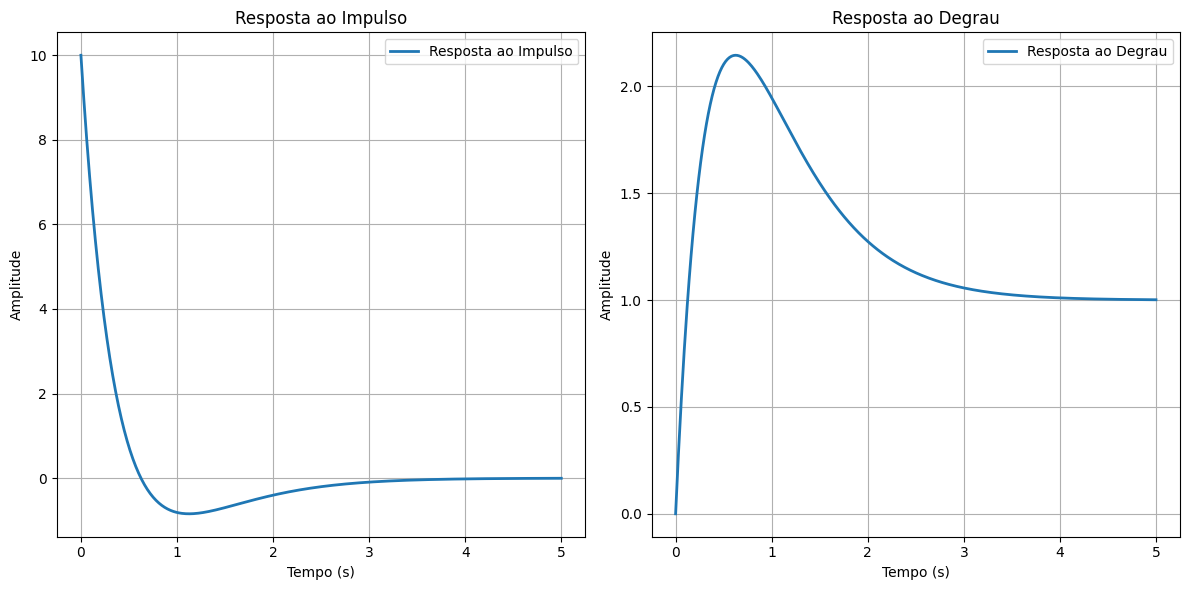

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Vetor de tempo
t= np.linspace(0, 5, 500)

# função de transferência
num = [10, 4]
dem = [1, 4, 4]
system = signal.TransferFunction(num, dem)

# Respostas
t, a = signal.impulse(system, T=t)
t, b = signal.step(system, T=t)

# Plot
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(t, a, label='Resposta ao Impulso', linewidth=2)
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.title('Resposta ao Impulso')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(t, b, label='Resposta ao Degrau', linewidth=2)
plt.xlabel('Tempo (s)')
plt.ylabel('Amplitude')
plt.title('Resposta ao Degrau')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

---

**6.** *Considere o sistema de 4ª ordem definido por $G(s) = \frac{6.32s^2 + 18s + 12.81}{s^4 + 6s^3 + 11.32s^2 + 18s + 12.81}$. Desenhe a curva de resposta ao degrau unitário desse sistema. Obtenha o tempo de subida, tempo de pico, máximo sobressinal e tempo de acomodação*

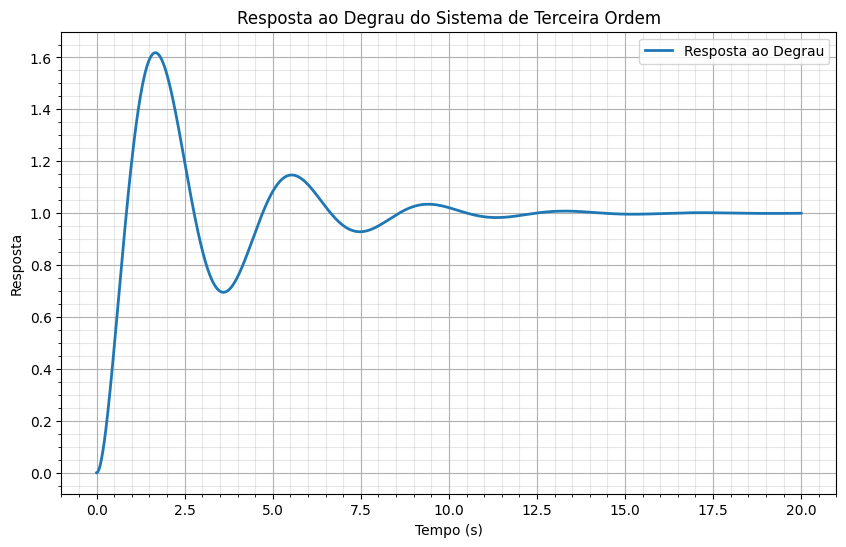

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Vetor de tempo
t = np.linspace(0, 20, 1000)

# Função de Transferência
num = [6.32, 18, 12.81]
dem = [1, 6, 11.32, 18, 12.81]
system = signal.TransferFunction(num, dem)

# Resposta
t, x = signal.step(system, T=t)

# Plot
plt.figure(figsize=(10,6))
plt.plot(t, x, label='Resposta ao Degrau', linewidth=2)
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta')
plt.title('Resposta ao Degrau do Sistema de Terceira Ordem')
plt.minorticks_on()              # ativa subdivisões menores
plt.grid(True, which='major')    # grid principal
plt.grid(True, which='minor', alpha=0.3)  # grid secundário
plt.legend()
plt.show()

"""
Analisando o gráfico, encontramos o tempo de subida de aproximadamente 0,8 segundos, 
o tempo de pico em torno de 1,7 segundos, o máximo sobressinal de cerca de 63% e 
o tempo de acomodação em torno de 11,3 segundos, considerando um critério de 2%.
"""

---

**7.** *Considere o sistema de malha fechada definido por $G(s) = \frac{\omega^{2}_n}{s^2 + 2\zeta\omega_ns + \omega^{2}_n}$.  Utilizando um loop for, escreva um programa para obter a resposta ao degrau unitário desse sistema para os seguintes casos:*  

*a) $\zeta = 0.3$ e $\omega_n = 1$*  
*b) $\zeta = 0.5$ e $\omega_n = 2$*  
*c) $\zeta = 0.7$ e $\omega_n = 4$*  
*d) $\zeta = 0.8$ e $\omega_n = 6$*  

*Apresente os gráficos das respostas em uma única figura, identificando adequadamente cada curva.*

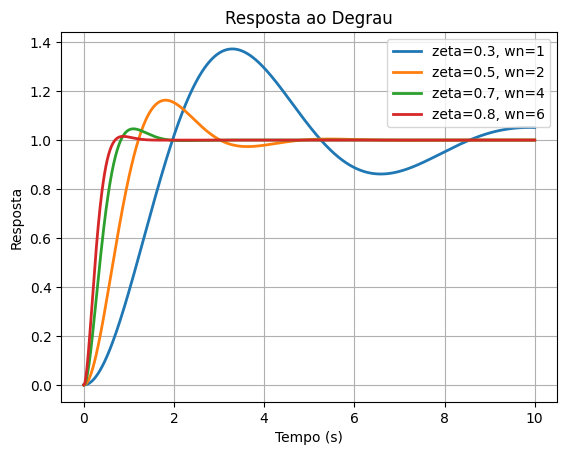

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Parâmetros
zeta = [0.3, 0.5, 0.7, 0.8]
wn = [1, 2, 4, 6]
item = ['a', 'b', 'c', 'd']

# Configuração do tempo de simulação (0 a 10 segundos)
t = np.linspace(0, 10, 1000)

# Loop
for z, w, i in zip(zeta, wn, item):
    # Função de Transferência
    num = [w**2]
    dem = [1, 2*z*w, w**2]
    system = signal.TransferFunction(num, dem)

    # Resposta ao degrau
    t, i = signal.step(system, T=t)

    # Plot
    plt.plot(t, i, label=f'zeta={z}, wn={w}', linewidth=2)

# Gráfico
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta')
plt.title(f'Resposta ao Degrau')
plt.grid()
plt.legend()
plt.show()

---

**8.** *Considerando a mesma função de transferência e entrada do exercício anterior, obtenha as respostas do sistema variando o valor de $\zeta$, para $\omega_n$ fixo em 1. Para quais valores de $\zeta$ o sistema é sub, super e criticamente amortecido?*

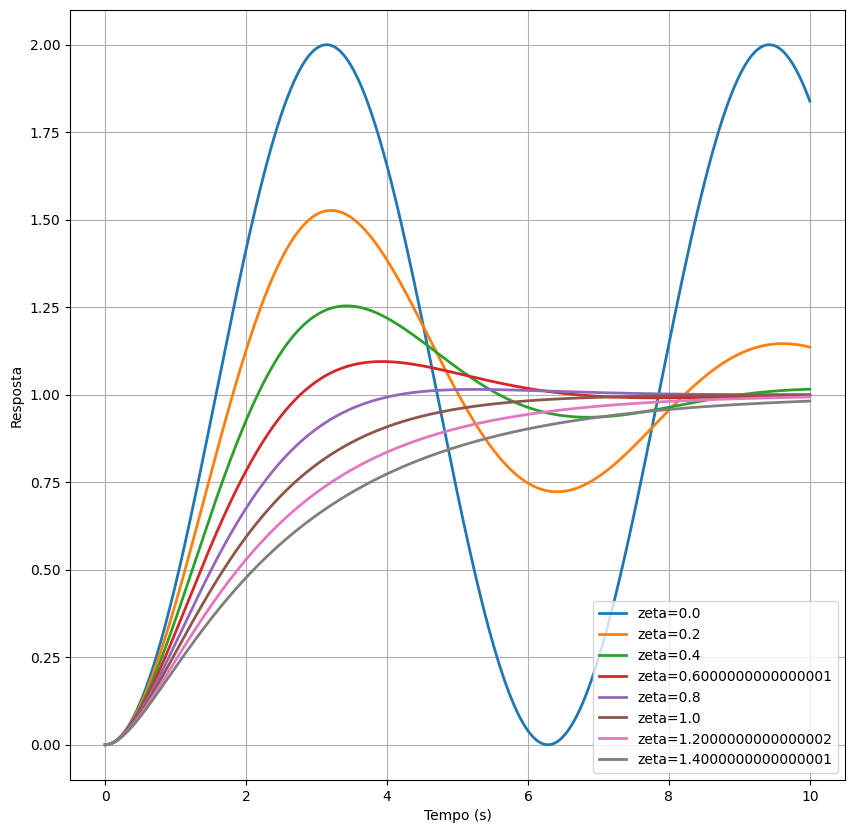

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

# Configuração do tempo de simulação (0 a 10 segundos)
t = np.linspace(0, 10, 1000)
wn = 1

plt.figure(figsize=(10, 10))
# Loop
for z in np.arange(0, 1.6, 0.2):
    # Função de Transferência
    num = [wn**2]
    dem = [1, 2*z*wn, wn**2]
    system = signal.TransferFunction(num, dem)

    # Resposta ao degrau
    t, x= signal.step(system, T=t)

    # Plot
    plt.plot(t, x, label=f'zeta={z}', linewidth=2)

# Gráfico
plt.xlabel('Tempo (s)')
plt.ylabel('Resposta')
plt.legend()
plt.grid()
plt.show()

"""
Subamortecido: zeta = 0.2, 0.4, 0.6, 0.8
Criticamente amortecido: zeta = 1.0
Superamortecido: zeta = 1.2, 1.4
zeta = 0 representa um sistema sem amortecimento, resultando em oscilações contínuas.
"""

**9.** *Pesquise e análise os comandos tf2ss e ss2tf, comentando-os. Mostre um exemplo para um sistema de segunda ordem de como utilizar ambos os comandos.*

In [11]:
"""
tf2ss (Transfer Function to State-Space).
    Este comando converte um sistema descrito por polinômios (numerador e denominador) para as matrizes de estados 
    A, B, C e D.
    Utilidade: É essencial quando você tem a dinâmica do sistema (via Transformada de Laplace) e precisa aplicar
    técnicas de controle moderno, como alocação de polos, observadores de estado ou controle LQR.
    Representação: x' = Ax + Bu
                   y =  Cx + Du

ss2tf (State-Space to Transfer Function).
    Faz o caminho inverso, transformando as matrizes de estados em uma função de transferência.
    Utilidade: Útil para encontrar a relação direta entre entrada e saída ou para analisar a resposta em frequência 
    (Bode, Nyquist) a partir de um modelo físico modelado por equações diferenciais de primeira ordem.

A seguir, um breve exemplo em python:
"""

import numpy as np
from scipy import signal

# 1. Definição dos coeficientes da Função de Transferência
num = [4]
den = [1, 2, 4]

print("--- Conversão: TF para SS ---")
# Utilizando tf2ss
A, B, C, D = signal.tf2ss(num, den)

print("Matriz A:\n", A)
print("Matriz B:\n", B)
print("Matriz C:\n", C)
print("Matriz D:\n", D)

print("\n--- Conversão: SS para TF ---")
# Utilizando ss2tf
num_rec, den_rec = signal.ss2tf(A, B, C, D)

print("Numerador recuperado:", num_rec.flatten())
print("Denominador recuperado:", den_rec)

--- Conversão: TF para SS ---
Matriz A:
 [[-2. -4.]
 [ 1.  0.]]
Matriz B:
 [[1.]
 [0.]]
Matriz C:
 [[0. 4.]]
Matriz D:
 [[0.]]

--- Conversão: SS para TF ---
Numerador recuperado: [0. 0. 4.]
Denominador recuperado: [1. 2. 4.]


**10.** *Analise/Comente o código:*
>> num = [ 0 2 2 5 ] ;  
>> den = [ 1 4 2 5 ] ;  
>> [ u , t ] = g e n si g ( ’ squa re ’ , 2 0 , 1 0 0 , . 0 1 ) ;  
>> l sim (num, den , u , t )  

*Os comandos impulse, stepinfo e ginput podem ajudar*

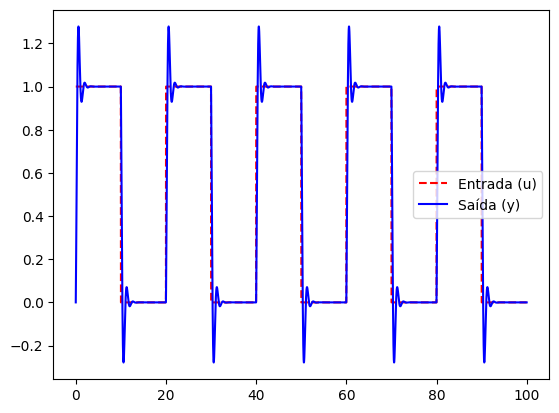

In [12]:
"""
No código apresentado, primeiramente define-se a Função de transferencia, pelo num e den,
depois cria-se um sinal periódico de onda quadrada com período 20, duração 100 e passo 0.01s
Por sim é feita a simulaçãolinear do sistema com o sinal de onda quadrada como entrada

Os comandos mensionados teriam as seguintes funções:
    - impulse: Mostraria a resposta do sistema a um pulso unitário (útil para ver a dinâmica natural sem entradas persistentes).
    - stepinfo: Forneceria dados numéricos exatos sobre a estabilidade, como o tempo de subida, overshoot (sobreclivagem) e tempo
    de acomodação.
    - ginput: Permite que você clique com o mouse no gráfico gerado para extrair as coordenadas $(t, y)$ de pontos específicos, como o valor de um pico de oscilação.
Abaixo, segue um equivalente em python para simulação.
"""

from scipy import signal
import numpy as np
import matplotlib.pyplot as plt

# Sistema
sys = signal.TransferFunction([2, 25], [1, 4, 25])

# Criar onda quadrada manualmente (já que não há gensig direto no scipy.signal)
t = np.arange(0, 100, 0.01)
u = 0.5 * (signal.square(2 * np.pi * (1/20) * t) + 1) # Onda entre 0 e 1

# Simulação
t, y, x = signal.lsim(sys, U=u, T=t)

plt.plot(t, u, 'r--', label='Entrada (u)')
plt.plot(t, y, 'b', label='Saída (y)')
plt.legend()
plt.show()